# Seasonal SOC + Cycle Diagnostics

Compare SOC trajectory and cycle usage for:
- 3‑month power + 1‑cycle cap
- 1‑month power + 1‑cycle cap


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")


In [2]:
# --- User configuration -----------------------------------------------------
PROJECT_DIR = Path("/home/fs01/jl2966/acorn-julia2/acorn-julia")
RUN_NAME = "low_RE_mod_elec_iter0"
CLIMATE_SCENARIO = "historical_1980_2019"

RUNS = {
    "pcap2160_1cycle": "stagel_3month_1cycle",   # update if your save_name differs
    "pcap720_1cycle": "stagel_1month_1cycle",    # update if your save_name differs
}

YEAR = 1985

output_root = PROJECT_DIR / "runs" / RUN_NAME / "outputs" / CLIMATE_SCENARIO
print("Runs:", RUNS)
print("Year:", YEAR)


Runs: {'pcap2160_1cycle': 'stagel_3month_1cycle', 'pcap720_1cycle': 'stagel_1month_1cycle'}
Year: 1985


In [3]:
def tidy_storage_df(df: pd.DataFrame, value_name: str) -> pd.DataFrame:
    meta_cols = [c for c in ["bus_id", "asset_type", "zone", "is_seasonal"] if c in df.columns]
    value_cols = [c for c in df.columns if c not in meta_cols]
    tidy = df.melt(id_vars=meta_cols, value_vars=value_cols,
                   var_name="timestamp", value_name=value_name)
    tidy["timestamp"] = pd.to_datetime(tidy["timestamp"], errors="coerce")
    tidy = tidy.dropna(subset=["timestamp"])
    return tidy


def total_timeseries(df: pd.DataFrame, value_name: str) -> pd.Series:
    return df.groupby("timestamp")[value_name].sum()


def load_seasonal_soc(run_dir: Path, year: int) -> pd.Series:
    df = pd.read_csv(run_dir / f"storage_state_seasonal_{year}.csv")
    # drop zone if present
    cols = [c for c in df.columns if c not in ("zone",)]
    df = df[cols]
    # remove header row if present
    if df.iloc[0, 0] == "bus_id":
        df = df.iloc[1:]
    # first col is bus_id
    value_cols = [c for c in df.columns if c != "bus_id"]
    df[value_cols] = df[value_cols].apply(pd.to_numeric, errors="coerce")
    # sum over buses
    soc = df[value_cols].sum(axis=0)
    soc.index = pd.to_datetime(soc.index, errors="coerce")
    soc = soc.dropna()
    return soc


In [4]:
# --- Load runs --------------------------------------------------------------
run_data = {}
for label, name in RUNS.items():
    run_dir = output_root / name
    discharge_seasonal = tidy_storage_df(pd.read_csv(run_dir / f"discharge_seasonal_{YEAR}.csv"), "discharge")
    charge_seasonal = tidy_storage_df(pd.read_csv(run_dir / f"charge_seasonal_{YEAR}.csv"), "charge")
    soc = load_seasonal_soc(run_dir, YEAR)

    run_data[label] = {
        "discharge": total_timeseries(discharge_seasonal, "discharge"),
        "charge": total_timeseries(charge_seasonal, "charge"),
        "soc": soc,
    }

print("Loaded:", list(run_data.keys()))

# Normalize tz-aware indices to tz-naive for plotting
for data in run_data.values():
    for k in ("soc", "charge", "discharge"):
        s = data[k]
        if hasattr(s.index, "tz") and s.index.tz is not None:
            s.index = s.index.tz_convert(None)


Loaded: ['pcap2160_1cycle', 'pcap720_1cycle']


## Seasonal SOC trajectory

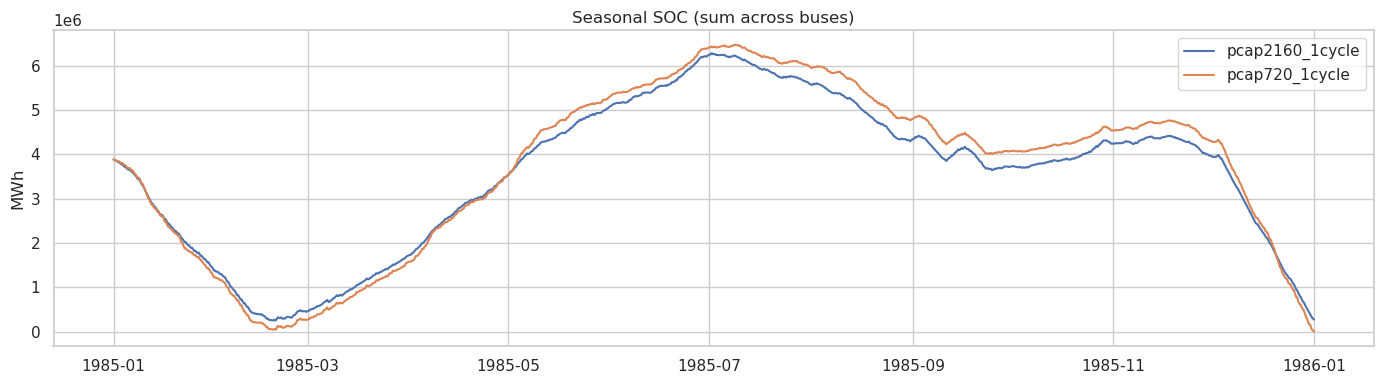

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
for label, data in run_data.items():
    ax.plot(data["soc"].index, data["soc"].values, label=label)
ax.set_title("Seasonal SOC (sum across buses)")
ax.set_ylabel("MWh")
ax.legend()
plt.tight_layout()
plt.show()


## Seasonal charge/discharge activity

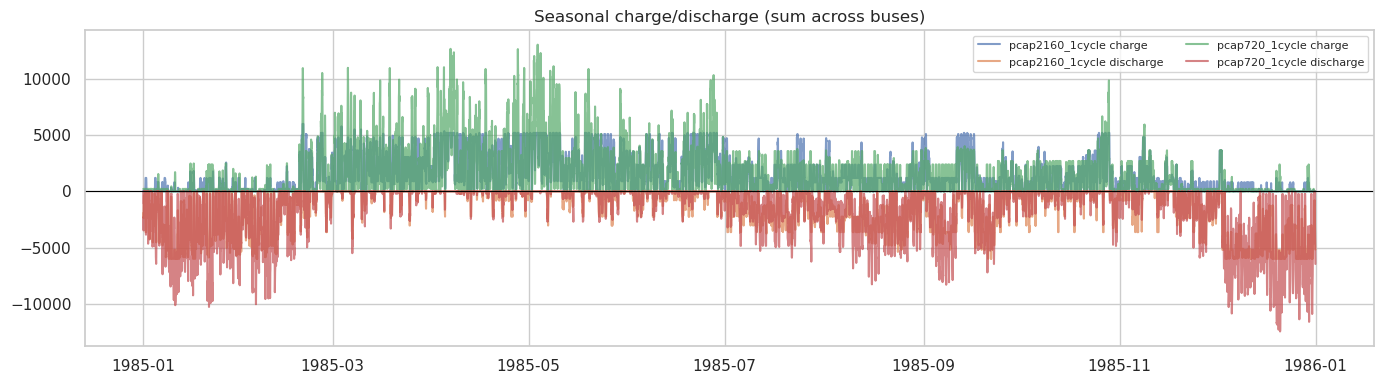

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
for label, data in run_data.items():
    ax.plot(data["charge"].index, data["charge"].values, label=f"{label} charge", alpha=0.7)
    ax.plot(data["discharge"].index, -data["discharge"].values, label=f"{label} discharge", alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Seasonal charge/discharge (sum across buses)")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


## Cycle usage summary

In [7]:
rows = []
for label, name in RUNS.items():
    run_dir = output_root / name
    data = run_data[label]
    total_dis = data["discharge"].sum()
    total_ch = data["charge"].sum()

    debug = pd.read_csv(run_dir / "_storage_debug.csv")
    if "is_seasonal" in debug.columns:
        seasonal = debug[debug["is_seasonal"] == 1]
        total_energy = seasonal["storage_capacity_mwh"].sum()
    else:
        total_energy = float('nan')

    cycles = total_dis / total_energy if total_energy and total_energy > 0 else 0.0

    rows.append({
        "run": label,
        "total_discharge_MWh": total_dis,
        "total_charge_MWh": total_ch,
        "total_energy_MWh": total_energy,
        "approx_cycles": cycles,
    })

display(pd.DataFrame(rows))


,run,total_discharge_MWh,total_charge_MWh,max_soc_MWh,approx_cycles
0,pcap2160_1cycle,1.295977e+07,1.310137e+07,6.284726e+06,2.062106
1,pcap720_1cycle,1.295977e+07,1.279030e+07,6.476719e+06,2.000978
